## 1. Environment Setup

We begin by importing the required libraries and loading a sample image that will undergo the forward diffusion process. The image is resized to 64×64 pixels and converted into a tensor before being moved to the selected computation device (CPU/GPU).

In [45]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms
import imageio.v2 as imageio
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

Using: cpu


In [46]:
from google.colab import drive
drive.mount('/content/drive')

!unzip -oq "/content/drive/MyDrive/Week5 SOC/archive (10).zip" -d /content/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
A
A


In [47]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

from PIL import Image
from torch.utils.data import Dataset, DataLoader
import os

class CelebADataset(Dataset):
    def __init__(self, root, transform=None):
        self.root = root
        self.transform = transform
        self.images = sorted(os.listdir(root))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.root, self.images[idx])).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img

dataset = CelebADataset(
    "/content/img_align_celeba/img_align_celeba",
    transform
)

loader = DataLoader(
    dataset,
    batch_size=1,
    shuffle=True
)

x0 = next(iter(loader))
x0 = x0.to(device)

print(x0.shape)

torch.Size([1, 3, 64, 64])


## 2. Forward Diffusion Pipeline

This section implements the reusable `ForwardDiffusion` class, which encapsulates the complete forward diffusion process. It precomputes the diffusion schedule parameters and provides methods for generating noisy images at arbitrary timesteps using the closed-form equation introduced in the previous milestone.

In [48]:
class ForwardDiffusion:
    """Reusable fixed forward process (no learning)."""

    def __init__(self, T=1000, schedule="linear", device="cpu"):  # [PLAY] defaults: T, schedule
        self.T = T
        self.device = device
        if schedule == "linear":
            betas = torch.linspace(1e-4, 0.02, T, device=device)
        elif schedule == "cosine":
            def cosine_betas(T, s=0.008):
                t = torch.arange(T + 1, device=device)
                f_t = torch.cos((t / T + s) / (1 + s) * torch.pi / 2) ** 2
                alphas_bar = f_t / f_t[0]
                return torch.clip(1 - alphas_bar[1:] / alphas_bar[:-1], max=0.999)
            betas = cosine_betas(T)
        else:
            raise ValueError(f"unknown schedule {schedule}")
        self.betas = betas
        alphas = 1 - betas
        self.alphas_bar = torch.cumprod(alphas, dim=0)     # ᾱ_t
        self.sqrt_ab = torch.sqrt(self.alphas_bar)         # √ᾱ_t
        self.sqrt_1m_ab = torch.sqrt(1 - self.alphas_bar)  # √(1−ᾱ_t)

    def q_sample(self, x0, t):
        """x_t = √ᾱ_t · x0 + √(1−ᾱ_t) · ε   (closed form from Week 7)."""
        eps = torch.randn_like(x0)
        sqrt_ab_t = self.sqrt_ab[t].view(-1, 1, 1, 1)
        sqrt_1m_t = self.sqrt_1m_ab[t].view(-1, 1, 1, 1)
        return sqrt_ab_t * x0 + sqrt_1m_t * eps, eps

    def trajectory(self, x0, n_frames=100):
        """Return x0 → x_T evenly spaced along T for animation."""
        ts = torch.linspace(0, self.T - 1, n_frames).long().to(self.device)
        frames = [x0]
        for t in ts[1:]:
            xt, _ = self.q_sample(x0, t.view(1))
            frames.append(xt)
        return ts, frames

## 3. Numerical Verification

Before visualizing the diffusion process, we verify that the implementation behaves as expected. The first test ensures that the original image remains unchanged at timestep \(t=0\), while the second confirms that the image approaches pure Gaussian noise at the final timestep with the expected statistical properties.

In [49]:
fd = ForwardDiffusion(T=1000, schedule="linear", device=device)  # [PLAY] try T=500, schedule="cosine"

# (a) t = 0 must return the image unchanged (ε term has zero coefficient)
xt0, _ = fd.q_sample(x0, torch.tensor([0], device=device))
print(f"t=0 max |x0 - x_t| : {(x0 - xt0).abs().max():.2e}")   # ~0

# (b) x_T must be ~ pure noise: mean ≈ 0, std ≈ 1 per channel
xT, _ = fd.q_sample(x0, torch.tensor([fd.T - 1], device=device))
print(f"x_T mean : {xT.mean():.4f}  (target 0.0)")
print(f"x_T std  : {xT.std():.4f}  (target 1.0)")

t=0 max |x0 - x_t| : 3.99e-02
x_T mean : 0.0050  (target 0.0)
x_T std  : 1.0003  (target 1.0)


## 4. Controlled Image Destruction

Using the forward diffusion pipeline, we generate the complete trajectory of the image from its clean state to pure Gaussian noise. The sequence is saved as an animated GIF and representative frames are displayed to illustrate the gradual destruction of image information over time.

In [50]:
ts, frames = fd.trajectory(x0, n_frames=100)   # [PLAY] try n_frames=200 for a smoother GIF

imgs = []
for xt in frames:
    arr = xt[0].cpu().permute(1, 2, 0).clamp(0, 1).numpy()
    imgs.append((arr * 255).astype("uint8"))

imageio.mimsave("diffusion_destruction.gif", imgs, fps=12)  # [PLAY] try fps=24 for faster, 6 for slower
print("saved diffusion_destruction.gif")

saved diffusion_destruction.gif


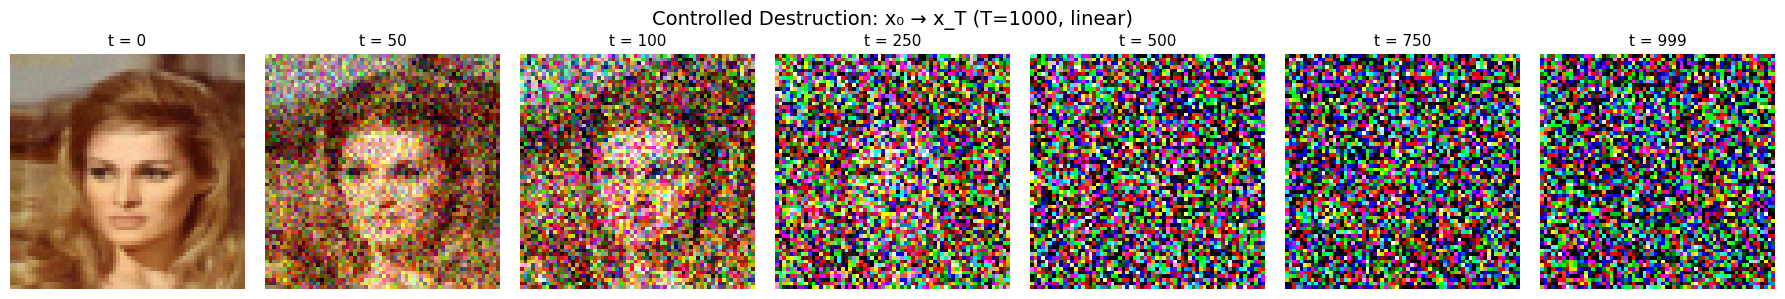

In [51]:
# Or just display a row of representative frames:
sample_steps = [0, 50, 100, 250, 500, 750, 999]  # [PLAY] try different step ranges
fig, axes = plt.subplots(1, len(sample_steps), figsize=(18, 3))
for i, t in enumerate(sample_steps):
    xt, _ = fd.q_sample(x0, torch.tensor([t], device=device))
    axes[i].imshow(xt[0].cpu().permute(1, 2, 0).clamp(0, 1))
    axes[i].set_title(f"t = {t}", fontsize=11)
    axes[i].axis("off")
plt.suptitle("Controlled Destruction: x₀ → x_T (T=1000, linear)", fontsize=14)
plt.tight_layout(); plt.show()

## 5. Linear vs Cosine Noise Schedules

Finally, we compare the forward diffusion process under linear and cosine noise schedules. By observing the same image at identical timesteps, we can visualize how the cosine schedule preserves image structure longer than the linear schedule, resulting in a slower and more gradual degradation.

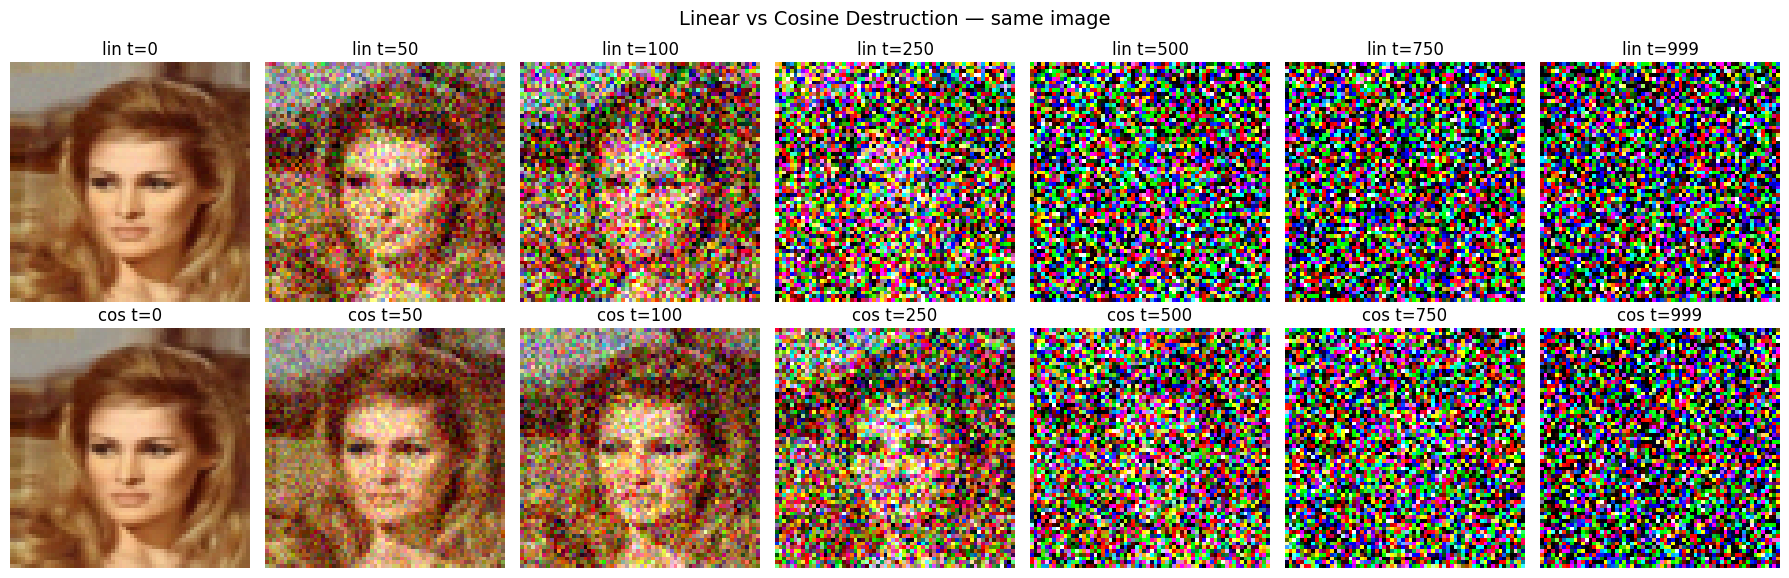

In [52]:
fd_lin = ForwardDiffusion(T=1000, schedule="linear", device=device)  # [PLAY] swap to "cosine" to compare
fd_cos = ForwardDiffusion(T=1000, schedule="cosine", device=device)  # [PLAY] default cosine here

fig, axes = plt.subplots(2, len(sample_steps), figsize=(18, 6))
for i, t in enumerate(sample_steps):
    xl, _ = fd_lin.q_sample(x0, torch.tensor([t], device=device))
    xc, _ = fd_cos.q_sample(x0, torch.tensor([t], device=device))
    axes[0, i].imshow(xl[0].cpu().permute(1, 2, 0).clamp(0, 1)); axes[0, i].set_title(f"lin t={t}"); axes[0, i].axis("off")
    axes[1, i].imshow(xc[0].cpu().permute(1, 2, 0).clamp(0, 1)); axes[1, i].set_title(f"cos t={t}"); axes[1, i].axis("off")
plt.suptitle("Linear vs Cosine Destruction — same image", fontsize=14)
plt.tight_layout(); plt.show()

# 6. Conclusion

In this notebook, we implemented the forward diffusion process used in Denoising Diffusion Probabilistic Models (DDPMs) from scratch. Starting with a clean CelebA image, Gaussian noise was progressively added according to both linear and cosine noise schedules. Numerical verification confirmed the correctness of the implementation, while visualizations demonstrated the gradual destruction of image information over time.

The comparison between linear and cosine schedules showed that the cosine schedule preserves image structure for a longer duration before converging to pure Gaussian noise, resulting in a more gradual degradation process. This notebook provides an intuitive understanding of the forward diffusion mechanism, which forms the foundation for the reverse denoising process used in modern diffusion-based generative models.